# 0 - Data Prep & Data Cleaning

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_excel('/content/drive/My Drive/Colab Data/indicatori_phd_clean_py_v2.xlsx')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = df.drop(columns=["Codicione_corso"])
df = df.set_axis(["Anno", "Indicatore", "Corso", "Ind_PHD", "Num", "Den", "Ind_ITA", "Ind_REGIONE" ], axis=1)
df

,Anno,Indicatore,Corso,Ind_PHD,Num,Den,Ind_ITA,Ind_REGIONE
0,2020,AVA3 - H.0.0.A - % iscritti al 1° anno dei cor...,"bioingegneria, bioinformatica e tecnologie per...",0.200000,2.0,10,0.340479,0.341270
1,2020,AVA3 - H.0.0.B - % dottori di ricerca che hann...,"bioingegneria, bioinformatica e tecnologie per...",0.250000,2.0,8,0.388832,0.450501
2,2020,AVA3 - H.0.0.C - % di borse di dottorato finan...,"bioingegneria, bioinformatica e tecnologie per...",0.000000,0.0,9,0.069126,0.116653
3,2020,AVA3 - H.0.0.D - % dottori che hanno trascorso...,"bioingegneria, bioinformatica e tecnologie per...",0.125000,1.0,8,0.217228,0.254727
4,2020,AVA3 - H.0.0.E - Numero di prodotti di ricerca...,"bioingegneria, bioinformatica e tecnologie per...",4.000000,32.0,8,11.618318,11.750834
...,...,...,...,...,...,...,...,...
428,2024,AVA3 - H.0.0.A - % iscritti al 1° anno dei cor...,translational and precision medicine,0.375000,6.0,16,0.450960,0.490971
429,2024,AVA3 - H.0.0.B - % dottori di ricerca che hann...,translational and precision medicine,0.000000,0.0,7,0.279087,0.217806
430,2024,AVA3 - H.0.0.C - % di borse di dottorato finan...,translational and precision medicine,0.615385,8.0,13,0.663954,0.720307
431,2024,AVA3 - H.0.0.D - % dottori che hanno trascorso...,translational and precision medicine,0.142857,1.0,7,0.170221,0.155803


In [ ]:
import pandas as pd
from statsmodels.stats.proportion import proportion_confint

# Conversione sicura numeratore e denominatore in numerici
df["Num"] = pd.to_numeric(df["Num"], errors="coerce")
df["Den"] = pd.to_numeric(df["Den"], errors="coerce")

# Funzione per classificare la robustezza
def classify_robustness(den):
    if pd.isna(den) or den == 0:
        return "Nessun dato"
    elif den >= 10:
        return "Verde (robusto)"
    elif den >= 5:
        return "Giallo (attenzione)"
    else:
        return "Rosso (critico)"

# Applica la funzione
df["Robustezza"] = df["Den"].apply(classify_robustness)

print(df.head(10))


   Anno                                         Indicatore  \
0  2020  AVA3 - H.0.0.A - % iscritti al 1° anno dei cor...   
1  2020  AVA3 - H.0.0.B - % dottori di ricerca che hann...   
2  2020  AVA3 - H.0.0.C - % di borse di dottorato finan...   
3  2020  AVA3 - H.0.0.D - % dottori che hanno trascorso...   
4  2020  AVA3 - H.0.0.E - Numero di prodotti di ricerca...   
5  2021  AVA3 - H.0.0.A - % iscritti al 1° anno dei cor...   
6  2021  AVA3 - H.0.0.B - % dottori di ricerca che hann...   
7  2021  AVA3 - H.0.0.C - % di borse di dottorato finan...   
8  2021  AVA3 - H.0.0.D - % dottori che hanno trascorso...   
9  2021  AVA3 - H.0.0.E - Numero di prodotti di ricerca...   

                                               Corso   Ind_PHD   Num  Den  \
0  bioingegneria, bioinformatica e tecnologie per...  0.200000   2.0   10   
1  bioingegneria, bioinformatica e tecnologie per...  0.250000   2.0    8   
2  bioingegneria, bioinformatica e tecnologie per...  0.000000   0.0    9   
3  bioing

In [ ]:
df[df["Robustezza"] == "Rosso (critico)"].groupby("Corso").size()

,0
Corso,
Linguistica,4
STORIA,6
"bioingegneria, bioinformatica e tecnologie per la salute",6
"computational mathematics, learning, and data science",8
"diritto privato, diritto romano e cultura giuridica europea",10
"diritto pubblico, giustizia penale e internazionale",11
medicina sperimentale,3
micro- and nano-electronics,3
public health and lifestyle,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 433 entries, 0 to 432
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Anno         433 non-null    int64  
 1   Indicatore   433 non-null    object 
 2   Corso        433 non-null    object 
 3   Ind_PHD      433 non-null    float64
 4   Num          433 non-null    float64
 5   Den          433 non-null    int64  
 6   Ind_ITA      433 non-null    float64
 7   Ind_REGIONE  433 non-null    float64
 8   Robustezza   433 non-null    object 
dtypes: float64(4), int64(2), object(3)
memory usage: 30.6+ KB


In [ ]:
num_col = df[["Anno", "Ind_PHD", "Num", "Den", "Ind_ITA", "Ind_REGIONE" ]]
cat_col = df[["Indicatore", "Corso", "Robustezza"]]
num_col = num_col.apply(pd.to_numeric, errors="coerce")
df = pd.concat([num_col, cat_col], axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 433 entries, 0 to 432
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Anno         433 non-null    int64  
 1   Ind_PHD      433 non-null    float64
 2   Num          433 non-null    float64
 3   Den          433 non-null    int64  
 4   Ind_ITA      433 non-null    float64
 5   Ind_REGIONE  433 non-null    float64
 6   Indicatore   433 non-null    object 
 7   Corso        433 non-null    object 
 8   Robustezza   433 non-null    object 
dtypes: float64(4), int64(2), object(3)
memory usage: 30.6+ KB


# 1 – **Trend temporali** per indicatore e corso.
L’obiettivo è:

- analizzare l’andamento 2020–2024 di ciascun indicatore per ogni corso,
- individuare eventuali miglioramenti o peggioramenti.


Mostro griglia per H.0.0.A – corsi: 23. Anni in X: [2020, 2021, 2022, 2023, 2024]


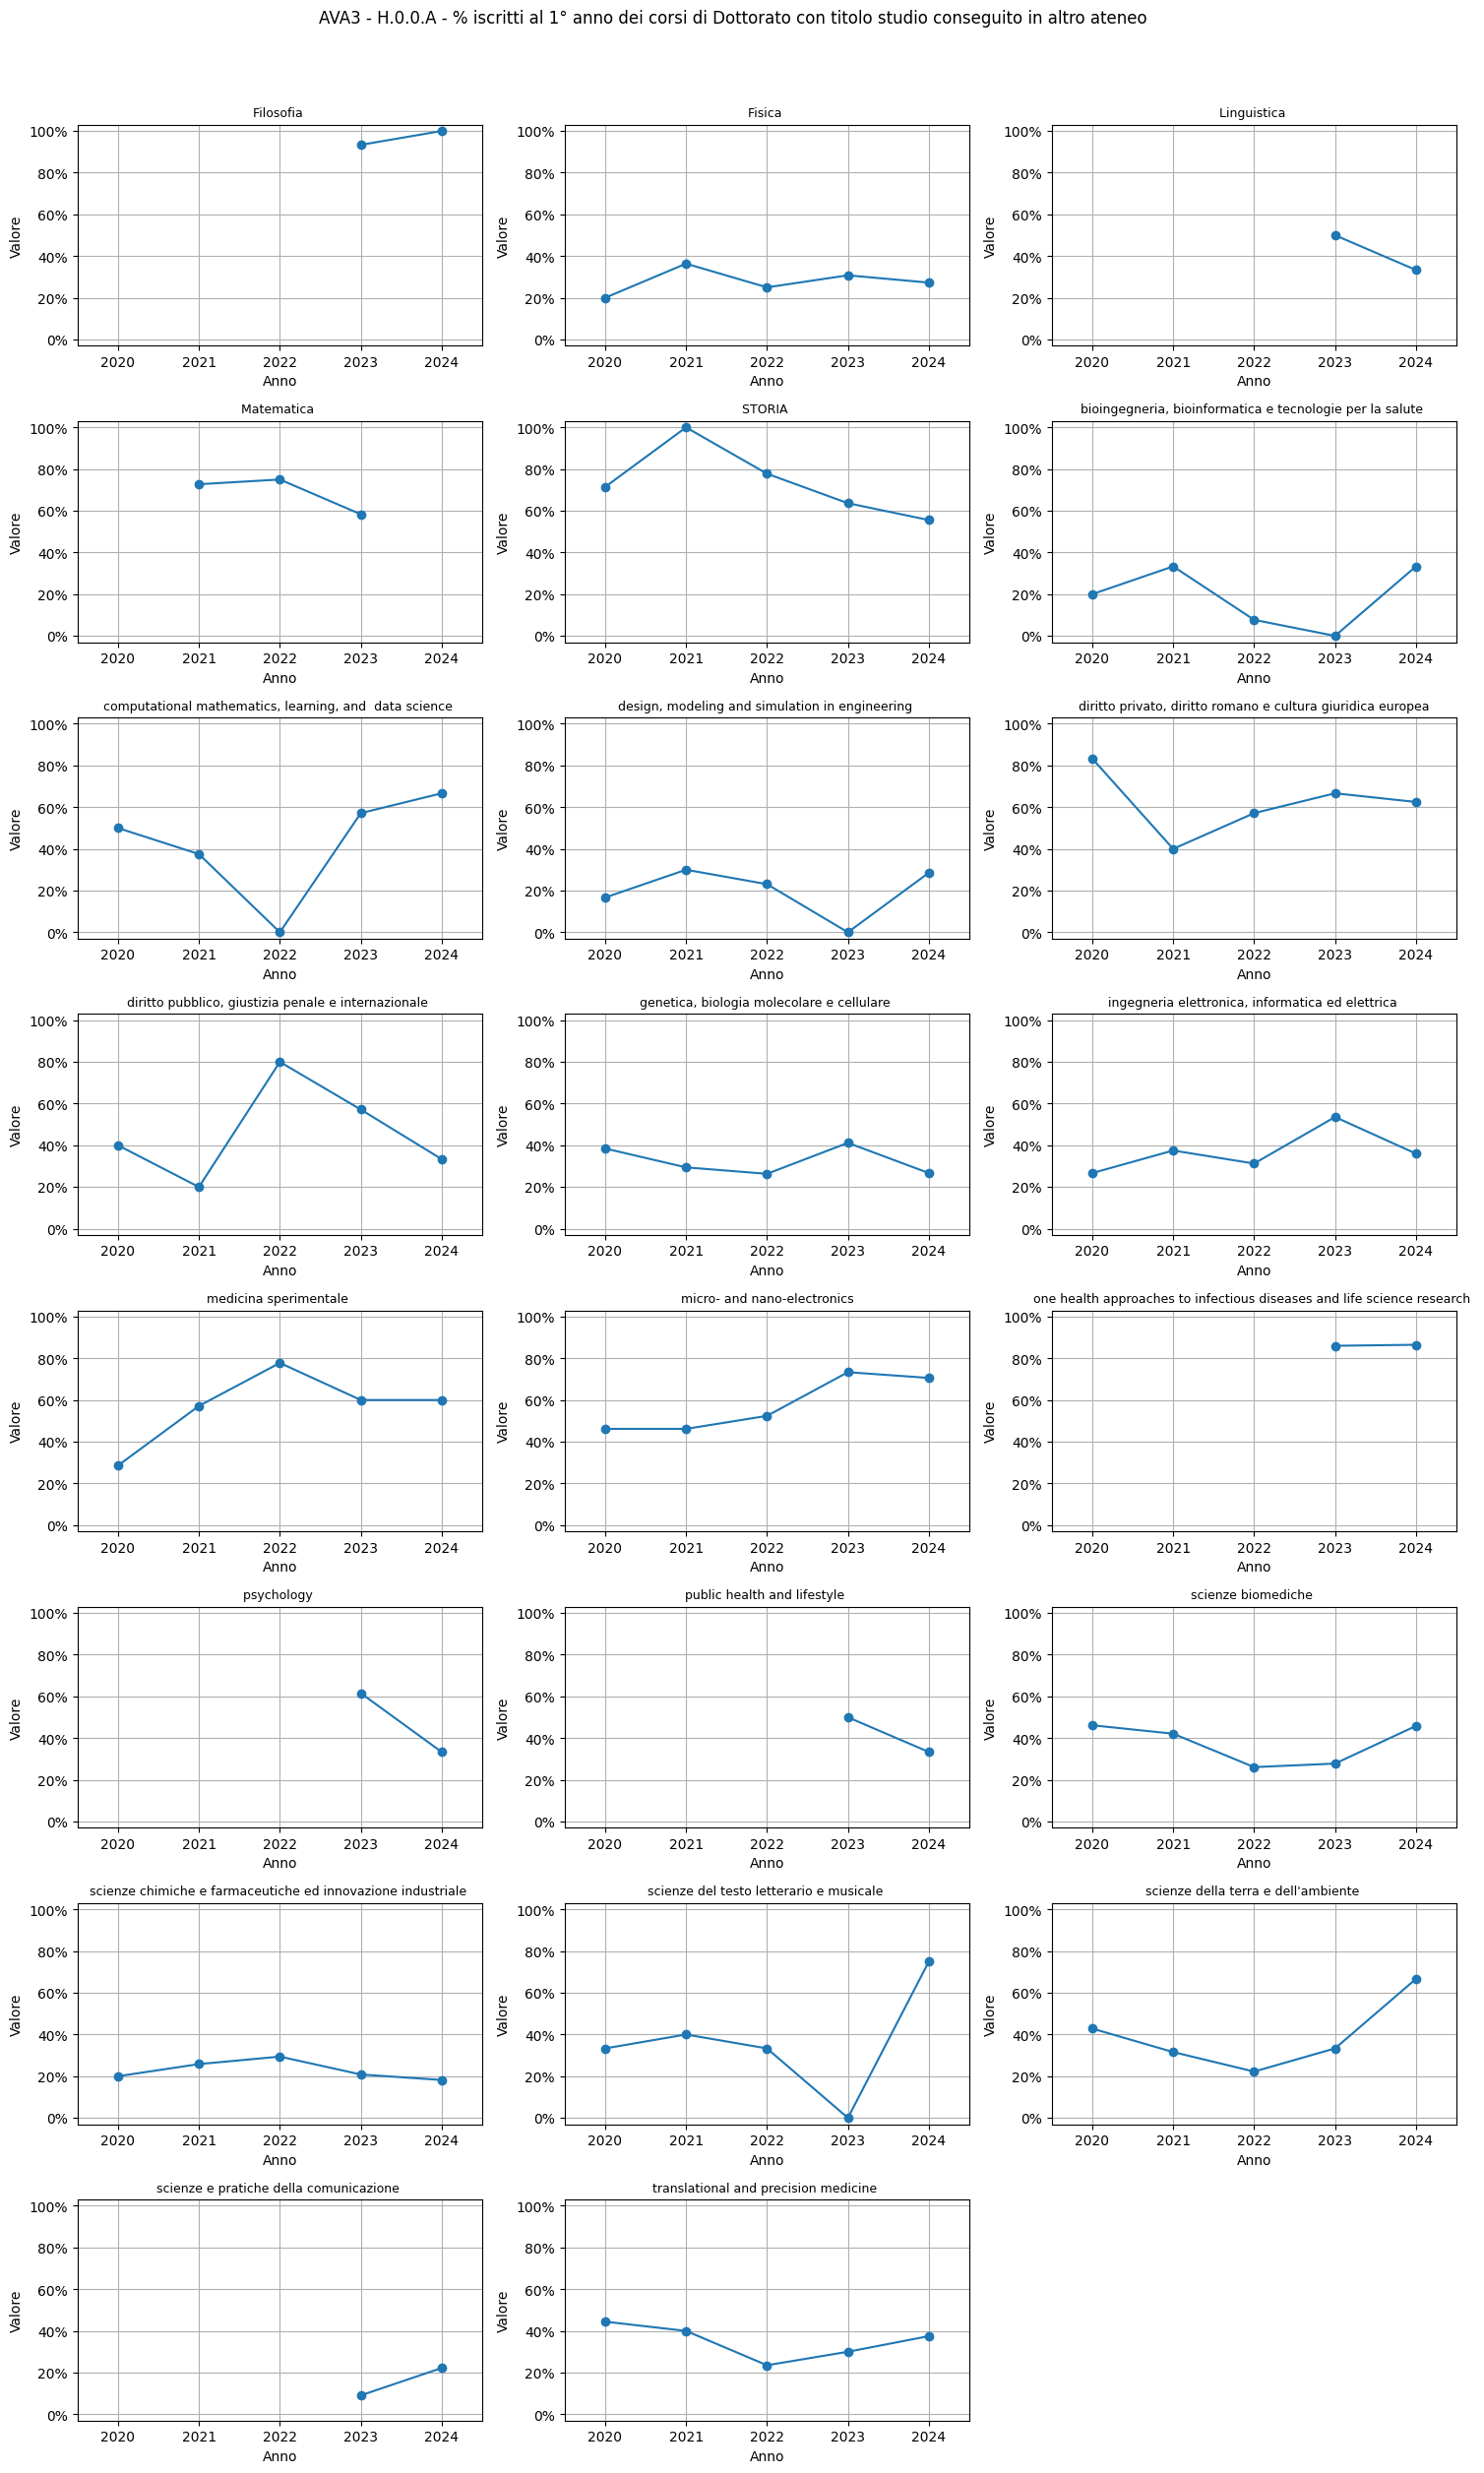

Mostro griglia per H.0.0.B – corsi: 17. Anni in X: [2020, 2021, 2022, 2023, 2024]


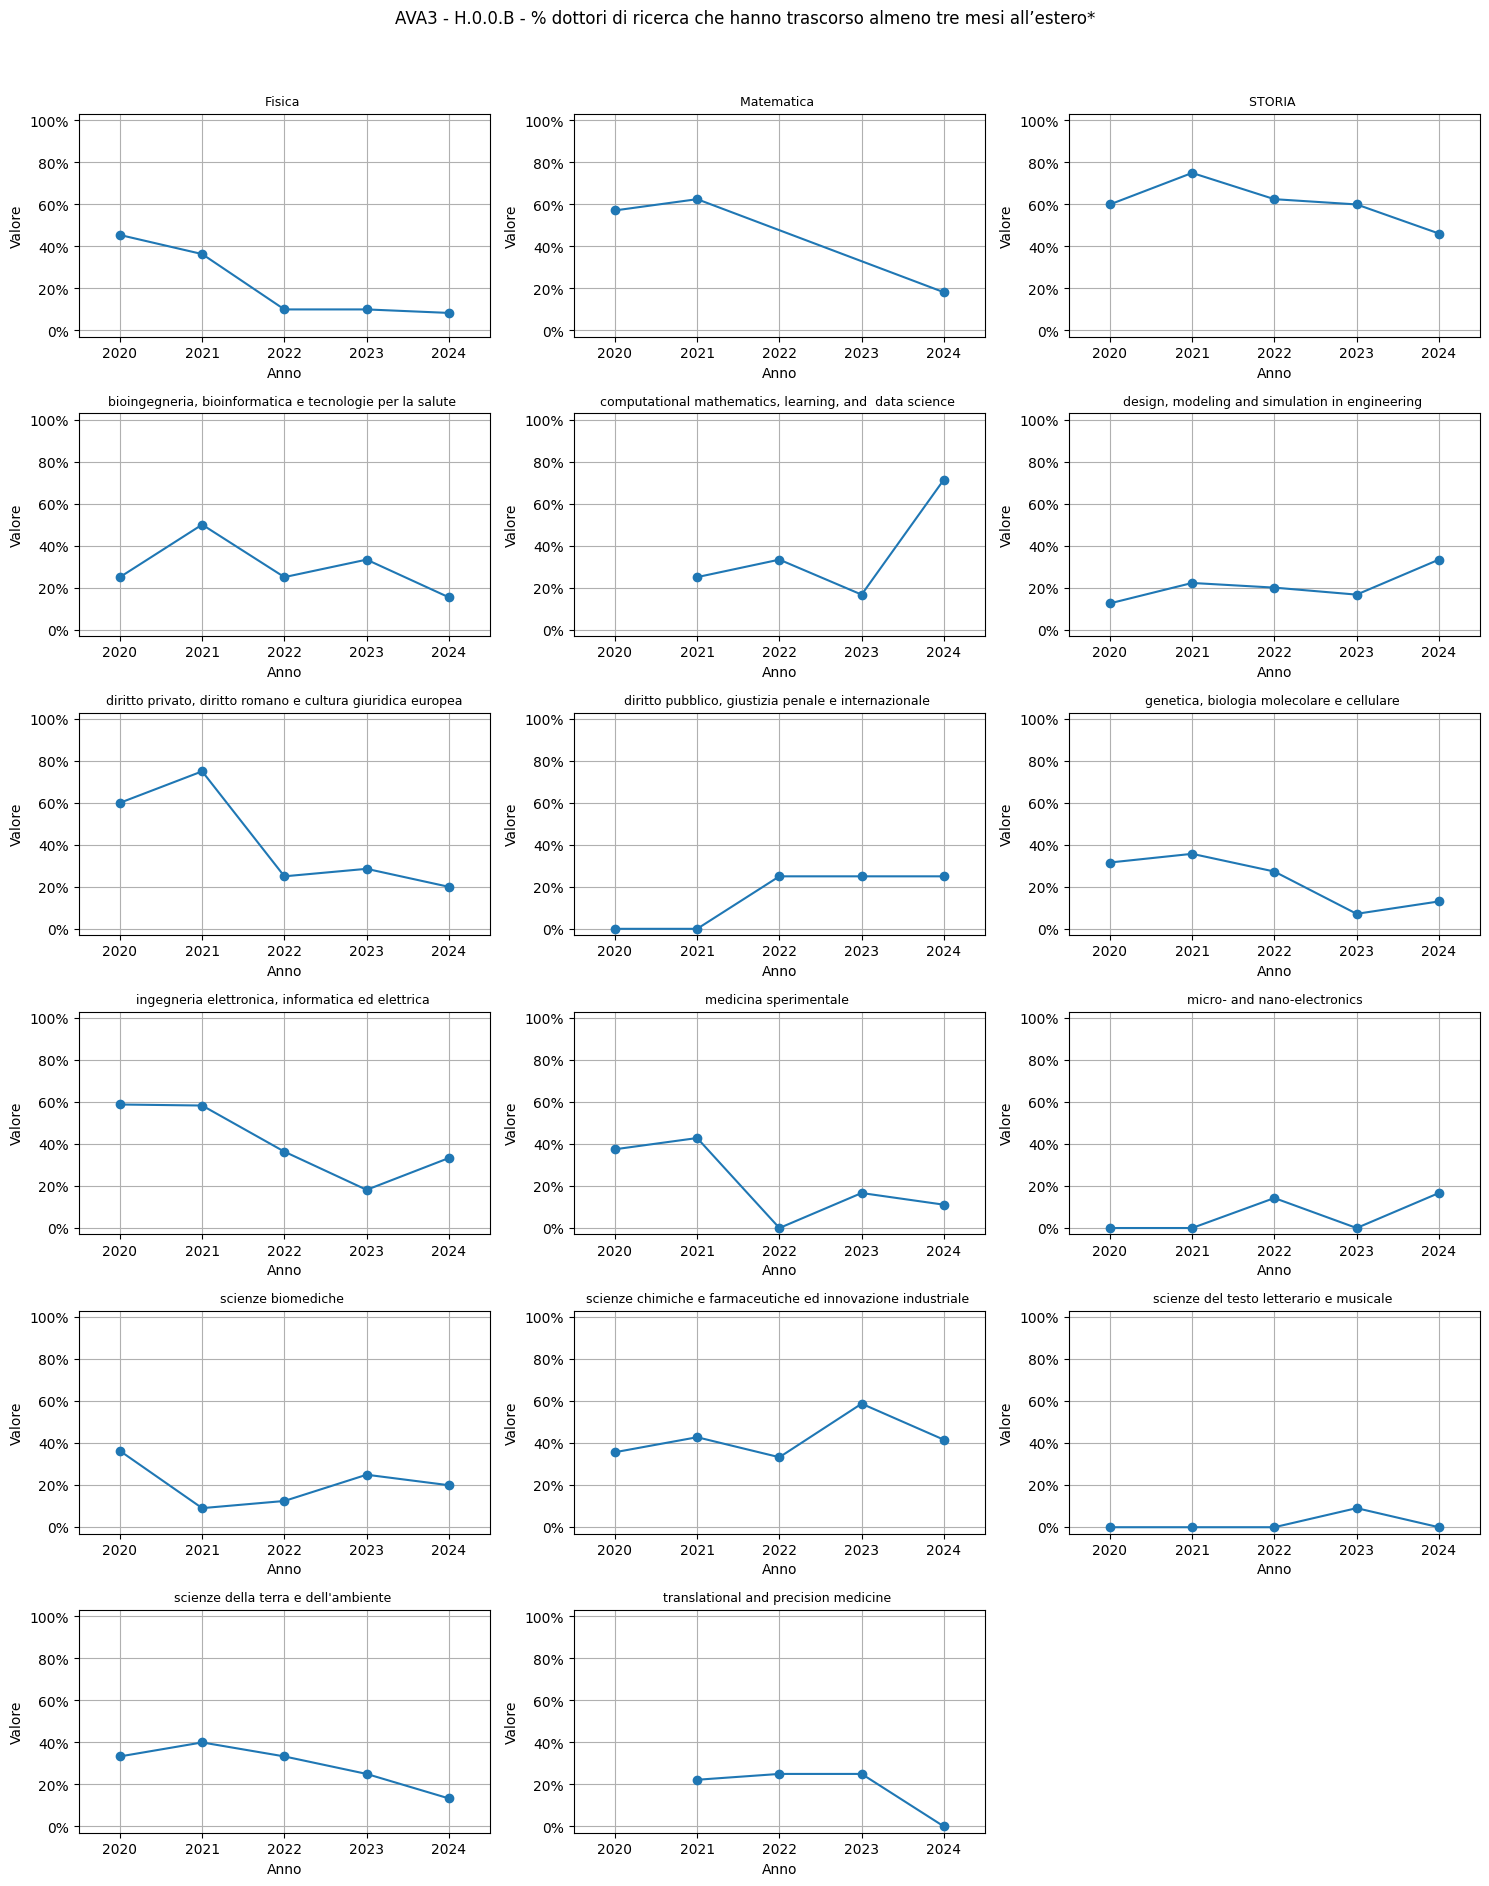

Mostro griglia per H.0.0.C – corsi: 23. Anni in X: [2020, 2021, 2022, 2023, 2024]


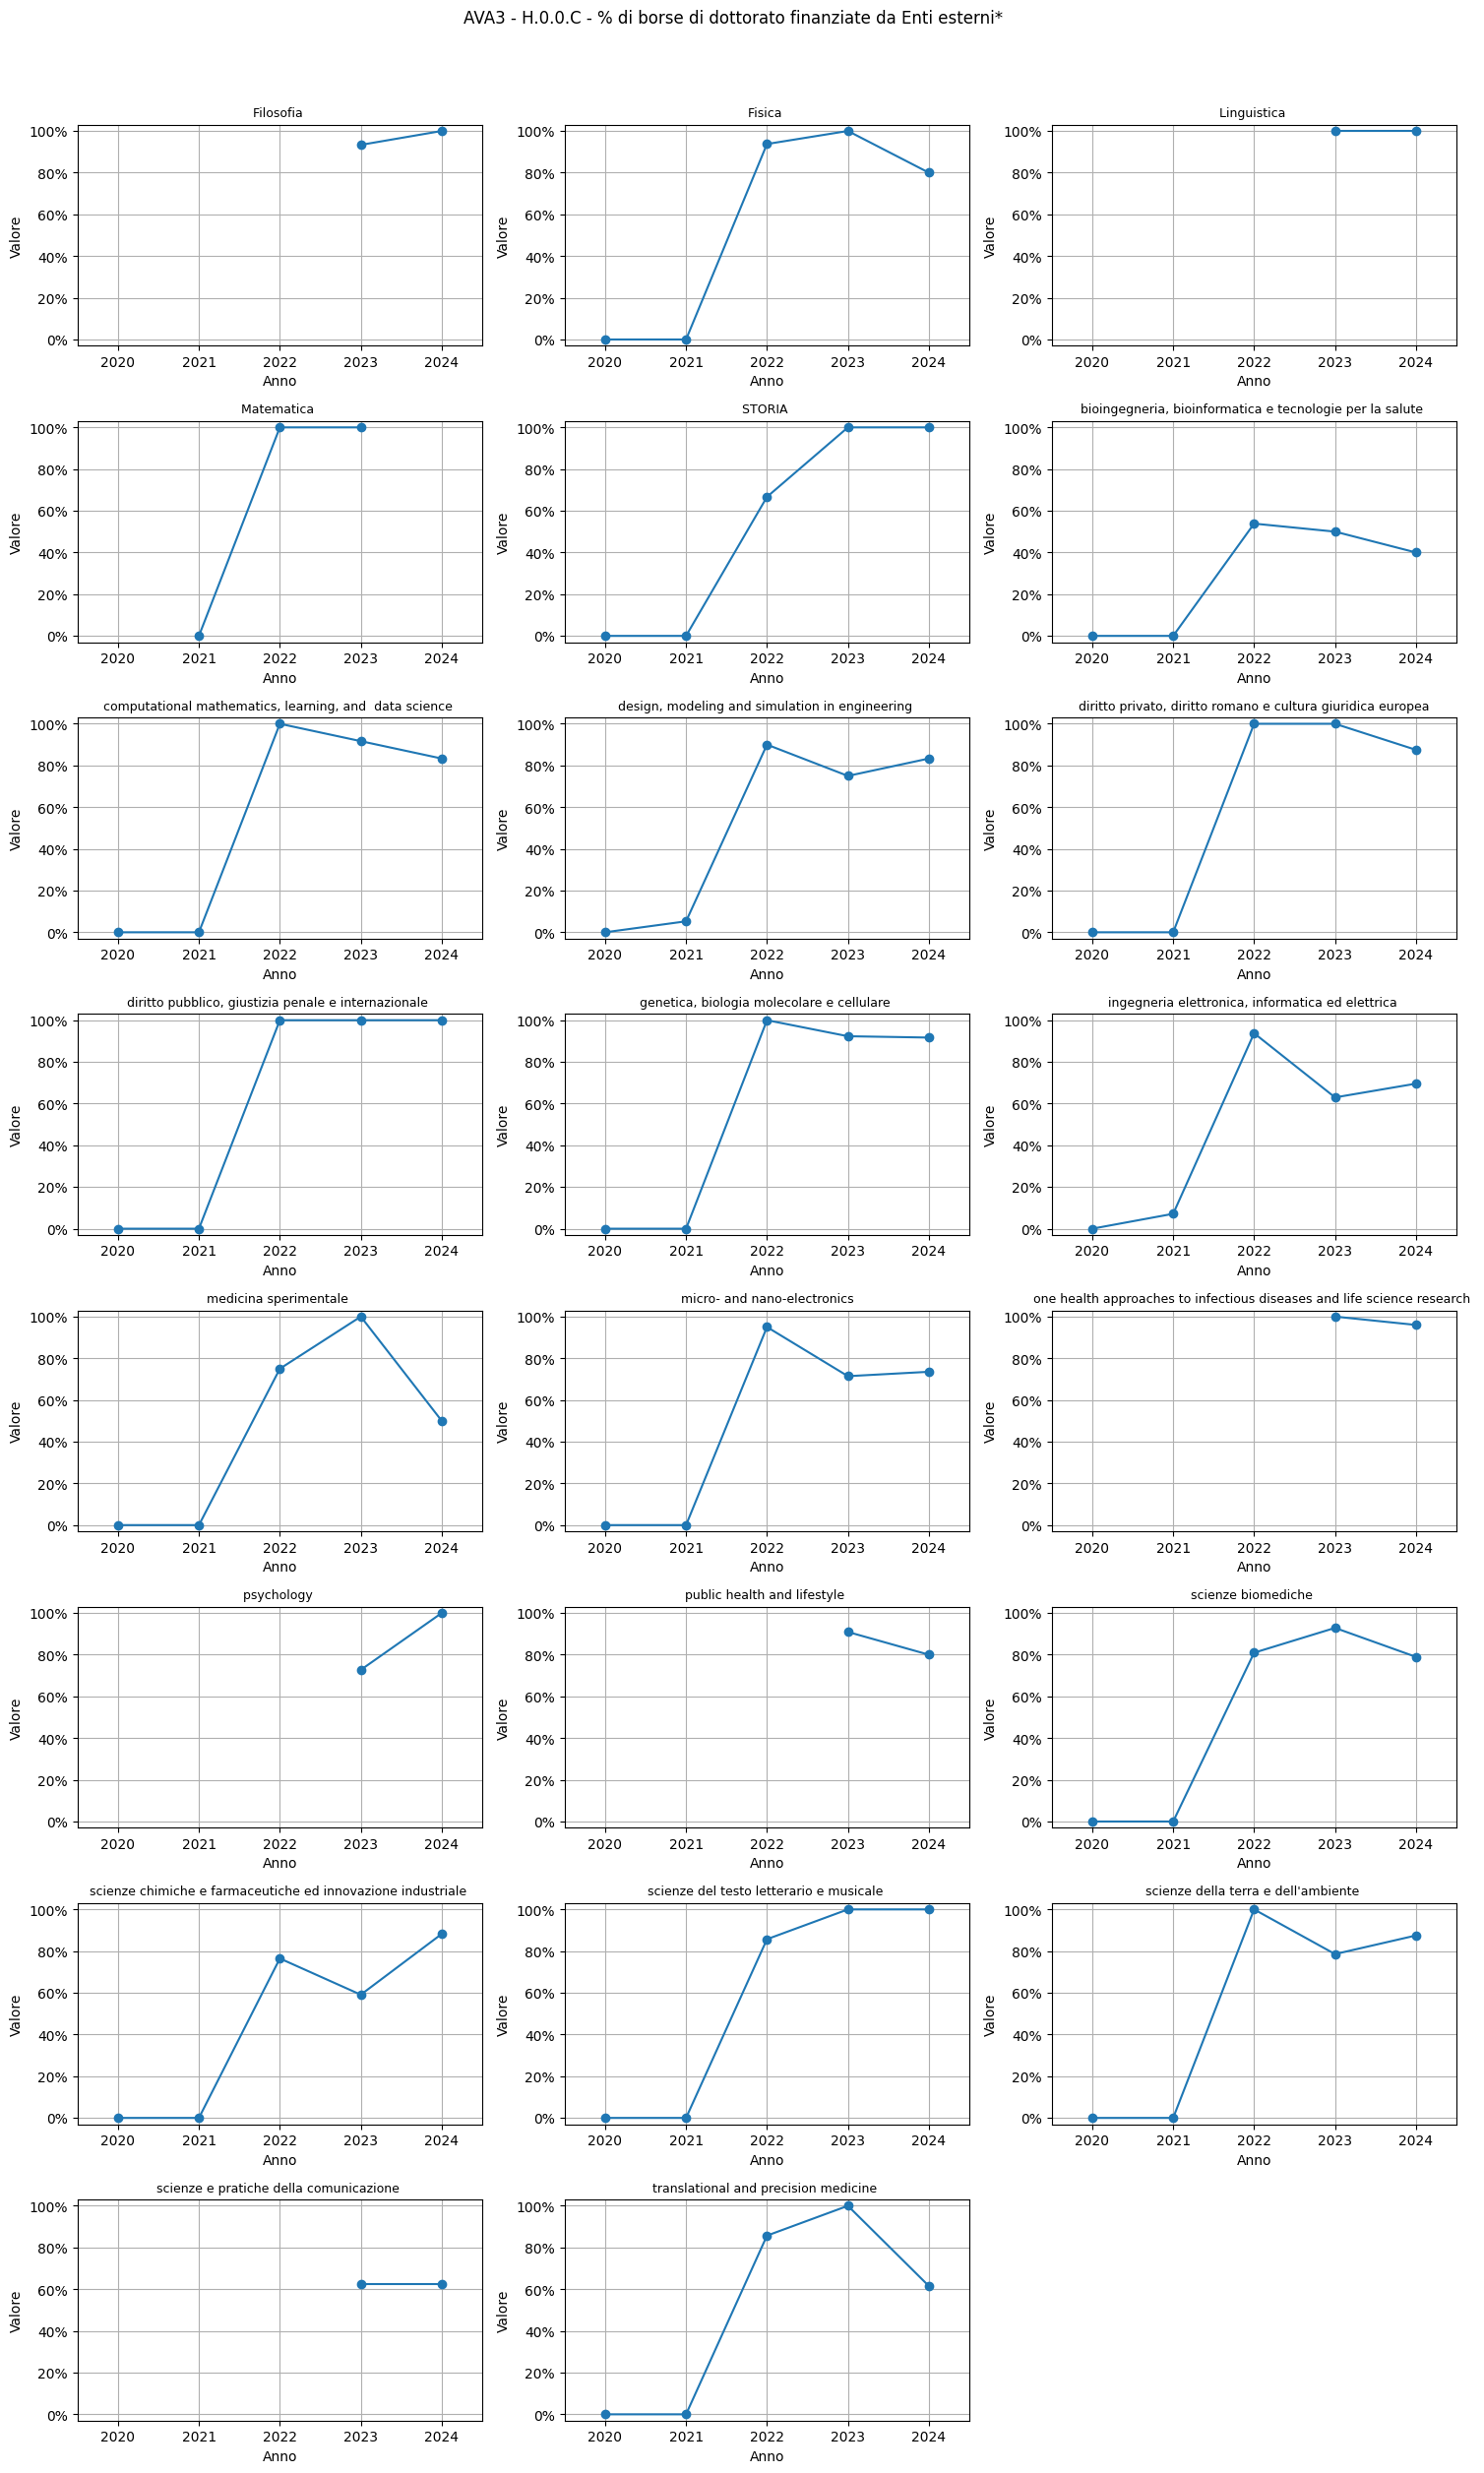

Mostro griglia per H.0.0.D – corsi: 17. Anni in X: [2020, 2021, 2022, 2023, 2024]


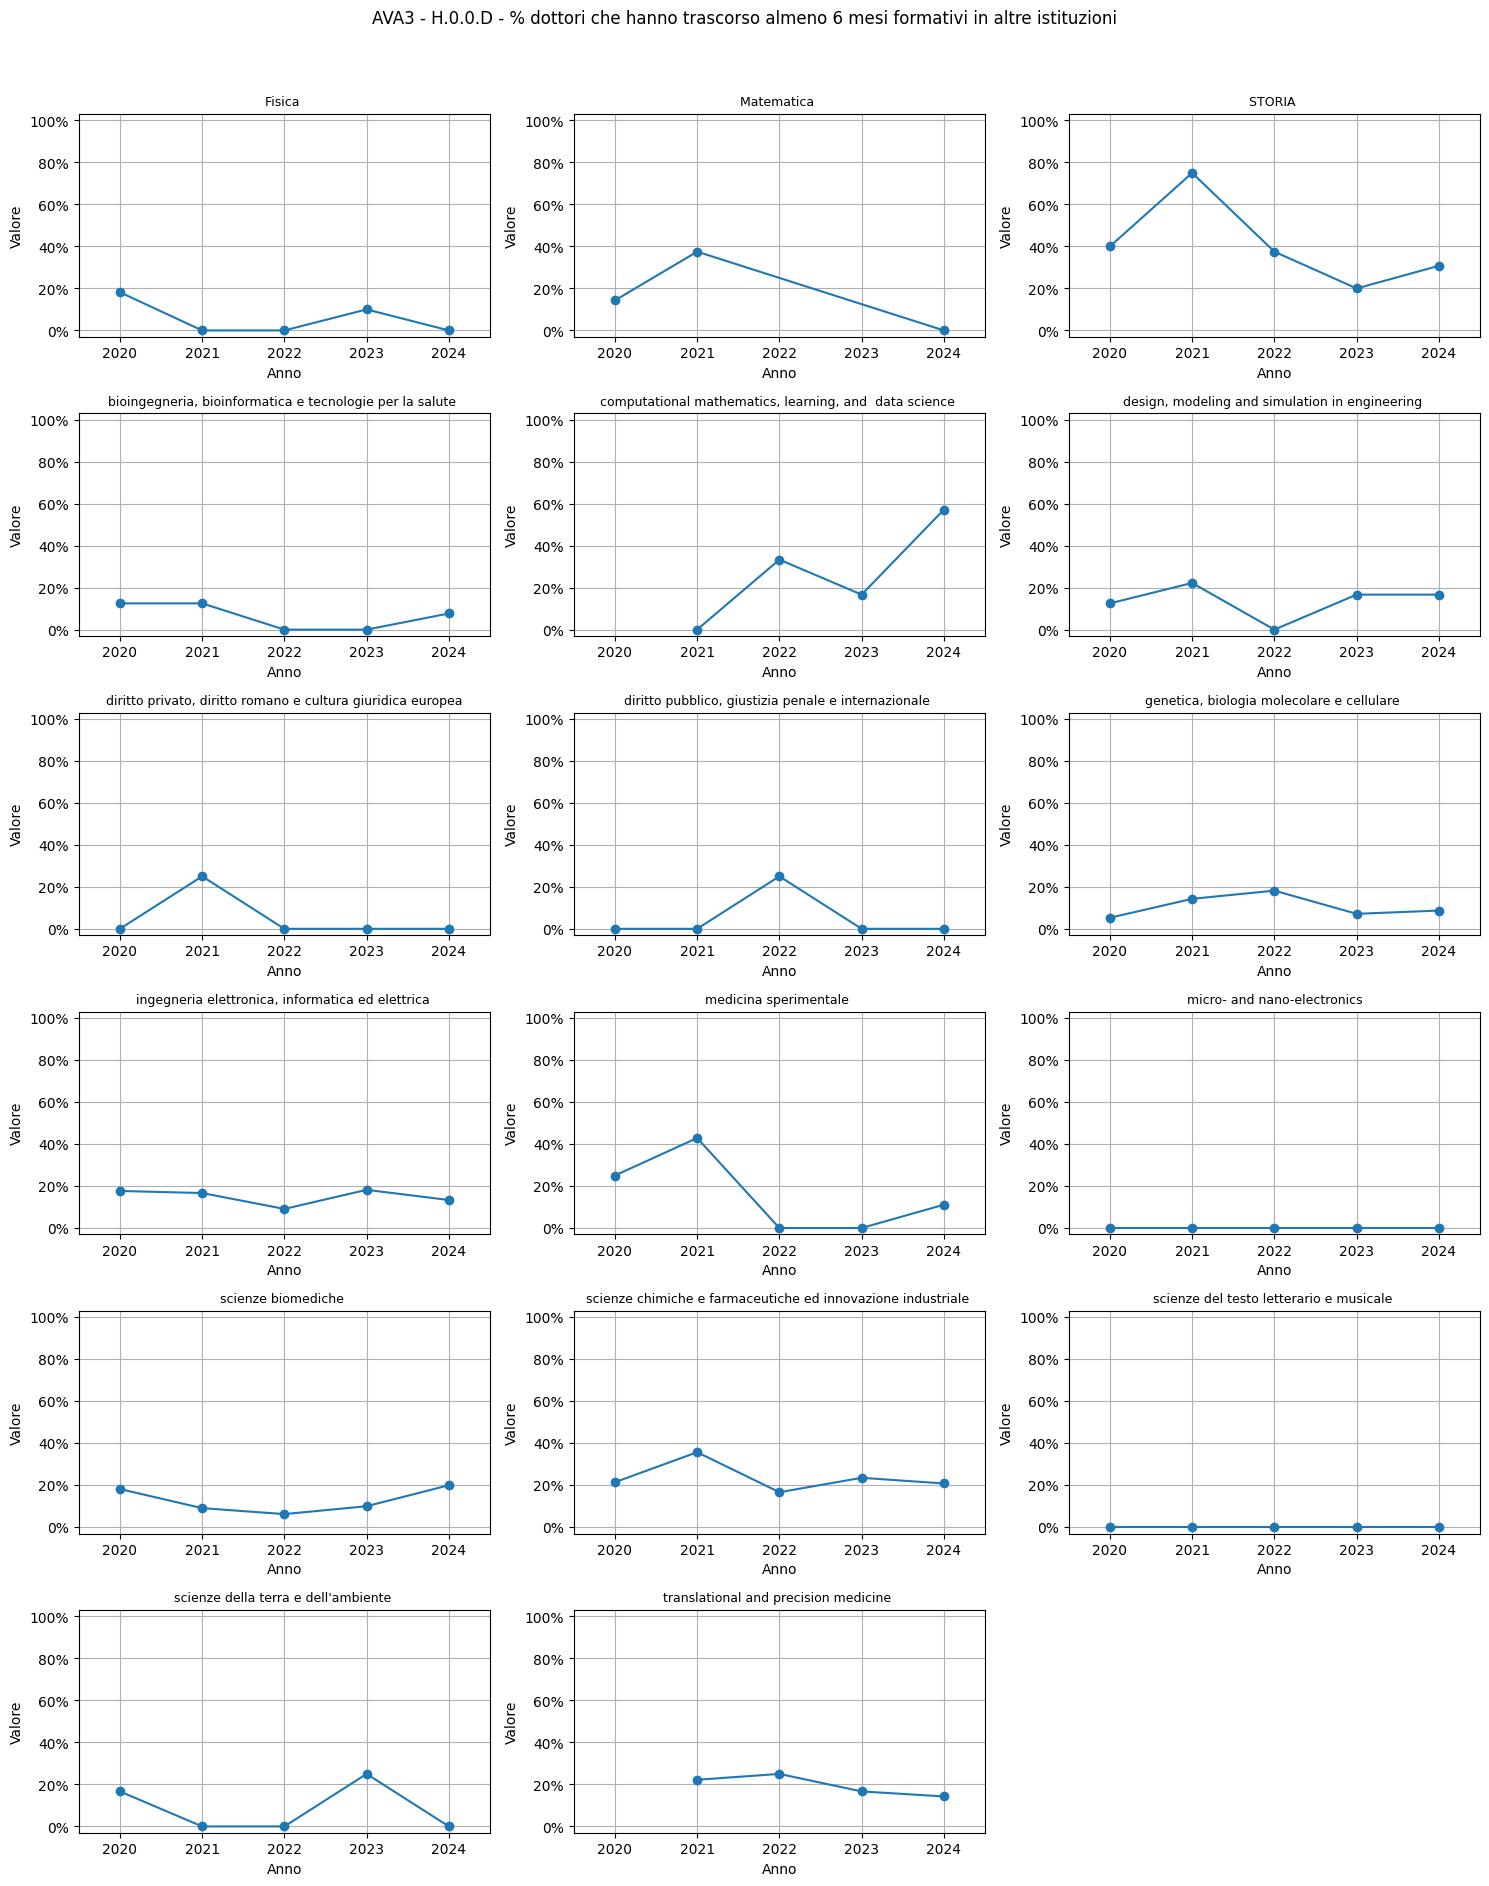

Mostro griglia per H.0.0.E – corsi: 17. Anni in X: [2020, 2021, 2022, 2023, 2024]


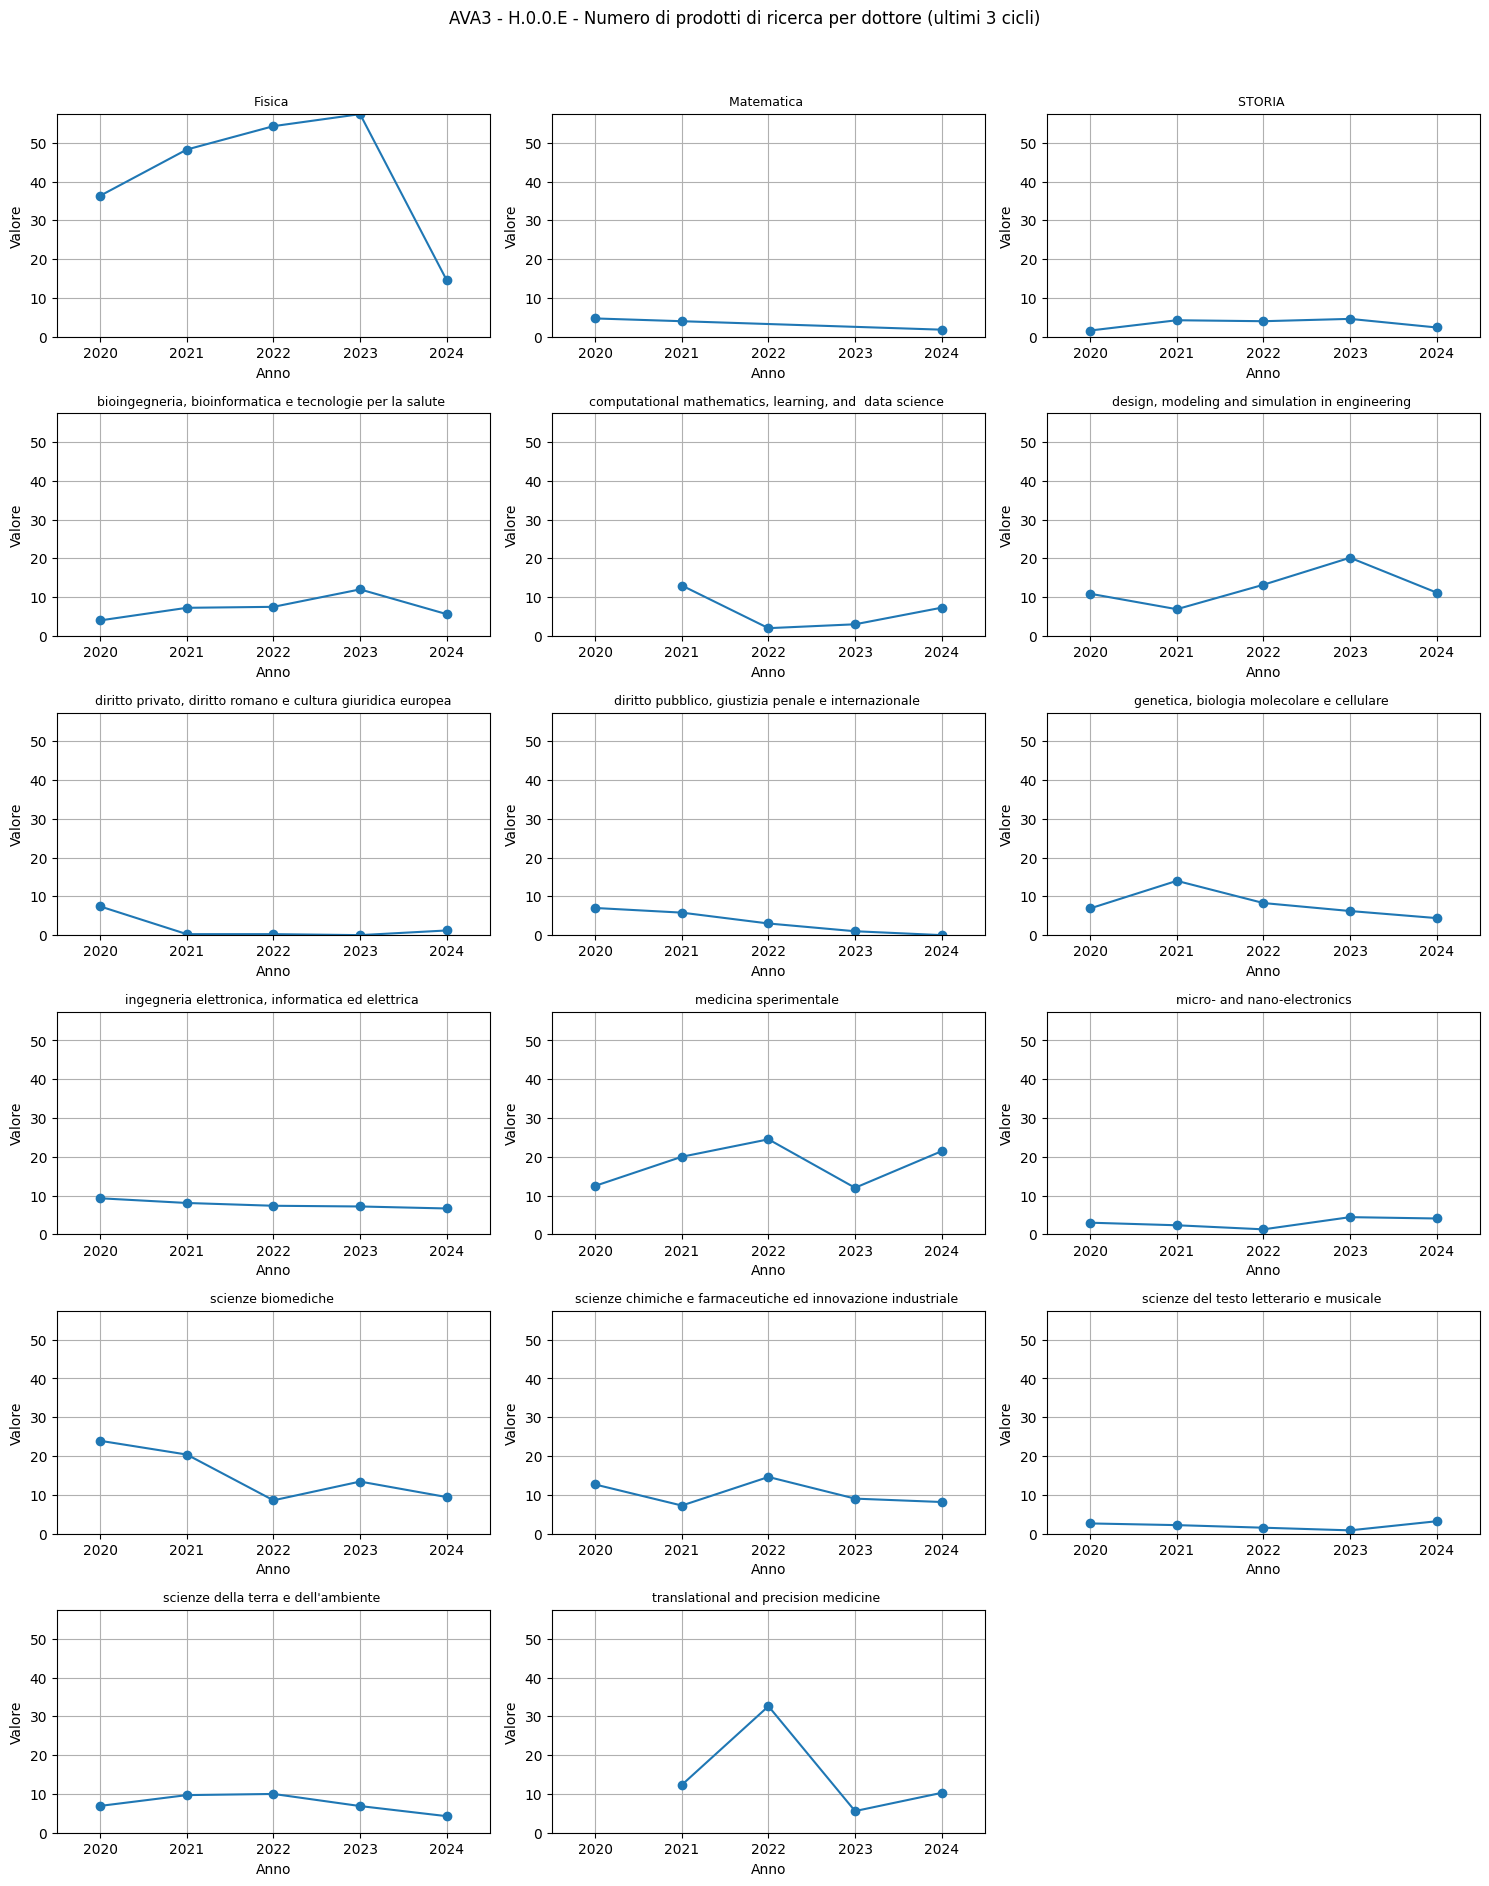

✅ Esecuzione completata: grafici mostrati a schermo (nessun export).


In [ ]:
# --- REQUISITI: df deve esistere con le colonne: 'Indicatore', 'Ind_PHD', 'Corso', 'Anno' ---

import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ============================================================================
# 0) PREP
# ============================================================================
dfw = df.copy()

# Anno numerico (se serve)
dfw['Anno'] = pd.to_numeric(dfw['Anno'], errors='coerce').astype('Int64')

# Valore numerico (eventuali "no_ind" -> NaN)
dfw['Ind_PHD_num'] = pd.to_numeric(dfw['Ind_PHD'], errors='coerce')

def estrai_codice_indicatore(titolo: str) -> str:
    if pd.isna(titolo):
        return None
    m = re.search(r'H\.0\.0\.[A-E]', str(titolo))
    return m.group(0) if m else None

dfw['Codice_ind'] = dfw['Indicatore'].apply(estrai_codice_indicatore)
dfw = dfw.sort_values(['Codice_ind', 'Corso', 'Anno'])

titoli_lunghi = (
    dfw[['Codice_ind','Indicatore']]
    .dropna()
    .drop_duplicates('Codice_ind')
    .set_index('Codice_ind')['Indicatore']
    .to_dict()
)

# Massimo globale per H.0.0.E (usato come Ymax fisso per tutti i grafici di E)
E_GLOBAL_MAX = dfw.loc[dfw['Codice_ind'].eq('H.0.0.E'), 'Ind_PHD_num'].max()
if pd.isna(E_GLOBAL_MAX) or not np.isfinite(E_GLOBAL_MAX) or E_GLOBAL_MAX <= 0:
    E_GLOBAL_MAX = 1.0  # fallback prudente

# ============================================================================
# 1) FUNZIONE: griglia sottoplot per un indicatore
#    - X: stessi anni e stesse posizioni per TUTTI i subplot dell'indicatore
#    - A–D: Y in percentuale, scala comune con micro-padding (-2%..102%)
#    - E  : Y fisso comune 0..E_GLOBAL_MAX
# ============================================================================
def plot_griglia_per_indicatore(df_ind, codice_ind, ncols=3, dpi=180, e_global_max=None, rotate_xticks=0):
    # Corsi con almeno un dato numerico
    corsi = (
        df_ind.groupby('Corso')['Ind_PHD_num']
        .apply(lambda s: s.notna().any())
        .pipe(lambda s: s[s].index.tolist())
    )
    if not corsi:
        print(f"[{codice_ind}] Nessun dato numerico disponibile: salto.")
        return

    # --- ANNI COMUNI (asse X uniforme per tutti i subplot di questo indicatore)
    anni_all = (
        df_ind['Anno']
        .dropna()
        .astype(int)
        .sort_values()
        .unique()
        .tolist()
    )
    if not anni_all:
        print(f"[{codice_ind}] Nessun anno valido: salto.")
        return

    # limiti X: centrati sui tick (slot uguali)
    xmin = anni_all[0] - 0.5
    xmax = anni_all[-1] + 0.5

    n = len(corsi)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(5*ncols, 3.2*nrows),
        squeeze=False,
        sharex=True  # stessa scala X per tutti i subplot
    )

    is_percent = (str(codice_ind) in ['H.0.0.A','H.0.0.B','H.0.0.C','H.0.0.D'])

    for i, corso in enumerate(corsi):
        r, c = divmod(i, ncols)
        ax = axes[r, c]

        g = (
            df_ind.loc[df_ind['Corso'].eq(corso), ['Anno','Ind_PHD_num']]
                 .dropna(subset=['Ind_PHD_num', 'Anno'])
                 .assign(Anno=lambda d: d['Anno'].astype(int))
                 .sort_values('Anno')
        )

        if g.empty:
            ax.text(0.5, 0.5, "no_ind", ha='center', va='center', transform=ax.transAxes)
            ax.set_axis_off()
            continue

        # Serie temporale
        ax.plot(g['Anno'], g['Ind_PHD_num'], marker='o')

        # Titoli/etichette
        ax.set_title(str(corso), fontsize=9)
        ax.set_xlabel("Anno")
        ax.set_ylabel("Valore")

        # --- X uniforme
        ax.set_xlim(xmin, xmax)
        ax.set_xticks(anni_all)
        # Forza le etichette visibili su tutti i subplot (sharex tende a nasconderle)
        ax.tick_params(axis='x', labelbottom=True)
        if rotate_xticks:
            ax.set_xticklabels([str(a) for a in anni_all], rotation=rotate_xticks, ha='right')

        ax.margins(x=0)  # niente padding orizzontale

        # --- Y in base al tipo di indicatore
        if is_percent:
            ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
            ax.yaxis.set_major_locator(mtick.MultipleLocator(0.2))
            pad = 0.03
            ax.set_ylim(-pad, 1 + pad)  # scala comune con micro-padding
        else:
            ymax = float(e_global_max) if e_global_max is not None else float(g['Ind_PHD_num'].max())
            if not np.isfinite(ymax) or ymax <= 0:
                ymax = 1.0
            ax.set_ylim(0, ymax)
            pad = 0.03

        ax.grid(True)

    # Spegne assi extra se la griglia non è piena
    total_axes = nrows * ncols
    for j in range(n, total_axes):
        r, c = divmod(j, ncols)
        axes[r, c].set_axis_off()

    titolo_fig = titoli_lunghi.get(codice_ind, f"Indicatore {codice_ind}")
    fig.suptitle(titoli_lunghi.get(codice_ind, f"Indicatore {codice_ind}"), fontsize=12, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    print(f"Mostro griglia per {codice_ind} – corsi: {len(corsi)}. Anni in X: {anni_all}")
    plt.show()
    plt.close(fig)

# ============================================================================
# 2) ESECUZIONE
# ============================================================================
codici = ['H.0.0.A','H.0.0.B','H.0.0.C','H.0.0.D','H.0.0.E']

for codice in codici:
    subset = dfw[dfw['Codice_ind'].eq(codice)]
    if codice == 'H.0.0.E':
        plot_griglia_per_indicatore(subset, codice_ind=codice, ncols=3, dpi=180, e_global_max=E_GLOBAL_MAX, rotate_xticks=0)
    else:
        plot_griglia_per_indicatore(subset, codice_ind=codice, ncols=3, dpi=180, rotate_xticks=0)

print("✅ Esecuzione completata: grafici mostrati a schermo (nessun export).")


# 2 - Benchmarking

In [ ]:
#Filtro semaforo: includiamo solo VERDE
mask_semaforo = df['Robustezza'].isin(['Verde (robusto)'])
dfb = df[mask_semaforo].copy()
dfb

,Anno,Ind_PHD,Num,Den,Ind_ITA,Ind_REGIONE,Indicatore,Corso,Robustezza
0,2020,0.200000,2.000000,10,0.340479,0.341270,AVA3 - H.0.0.A - % iscritti al 1° anno dei cor...,"bioingegneria, bioinformatica e tecnologie per...",Verde (robusto)
10,2022,0.076923,1.153846,15,0.369601,0.350500,AVA3 - H.0.0.A - % iscritti al 1° anno dei cor...,"bioingegneria, bioinformatica e tecnologie per...",Verde (robusto)
12,2022,0.538462,5.923077,11,0.682092,0.593114,AVA3 - H.0.0.C - % di borse di dottorato finan...,"bioingegneria, bioinformatica e tecnologie per...",Verde (robusto)
21,2024,0.153846,1.692308,11,0.402322,0.393985,AVA3 - H.0.0.B - % dottori di ricerca che hann...,"bioingegneria, bioinformatica e tecnologie per...",Verde (robusto)
23,2024,0.076923,0.846154,11,0.214621,0.218045,AVA3 - H.0.0.D - % dottori che hanno trascorso...,"bioingegneria, bioinformatica e tecnologie per...",Verde (robusto)
...,...,...,...,...,...,...,...,...,...
425,2023,1.000000,10.000000,10,0.724090,0.668653,AVA3 - H.0.0.C - % di borse di dottorato finan...,translational and precision medicine,Verde (robusto)
426,2023,0.166667,2.000000,12,0.176382,0.139706,AVA3 - H.0.0.D - % dottori che hanno trascorso...,translational and precision medicine,Verde (robusto)
427,2023,5.583333,67.000000,12,12.998496,13.049632,AVA3 - H.0.0.E - Numero di prodotti di ricerca...,translational and precision medicine,Verde (robusto)
428,2024,0.375000,6.000000,16,0.450960,0.490971,AVA3 - H.0.0.A - % iscritti al 1° anno dei cor...,translational and precision medicine,Verde (robusto)


In [ ]:
# Delta vs nazionale e vs macroregione per OGNI record (anno×corso×indicatore)
dfb['Delta_vs_ITA'] = (dfb['Ind_PHD'] - dfb['Ind_ITA']) / dfb['Ind_ITA'] * 100
dfb['Delta_vs_REG'] = (dfb['Ind_PHD'] - dfb['Ind_REGIONE']) / dfb['Ind_REGIONE'] * 100

# (Opzionale) anteprima con colonne essenziali
cols_view = ['Anno','Indicatore','Corso','Ind_PHD','Ind_ITA','Ind_REGIONE','Delta_vs_ITA','Delta_vs_REG','Den','Robustezza']
dfb[cols_view].head(10)

dfb.to_excel("indicatori_phd_con_delta.xlsx", index=False)

,Indicatore,Corso,Gap_medio_vs_ITA
0,AVA3 - H.0.0.A - % iscritti al 1° anno dei cor...,Filosofia,85.504528
1,AVA3 - H.0.0.A - % iscritti al 1° anno dei cor...,Fisica,-22.738802
2,AVA3 - H.0.0.A - % iscritti al 1° anno dei cor...,Matematica,88.232223
3,AVA3 - H.0.0.A - % iscritti al 1° anno dei cor...,STORIA,36.222116
4,AVA3 - H.0.0.A - % iscritti al 1° anno dei cor...,"bioingegneria, bioinformatica e tecnologie per...",-60.223385


Indicatore          0
Corso               0
Gap_medio_vs_ITA    0
dtype: int64


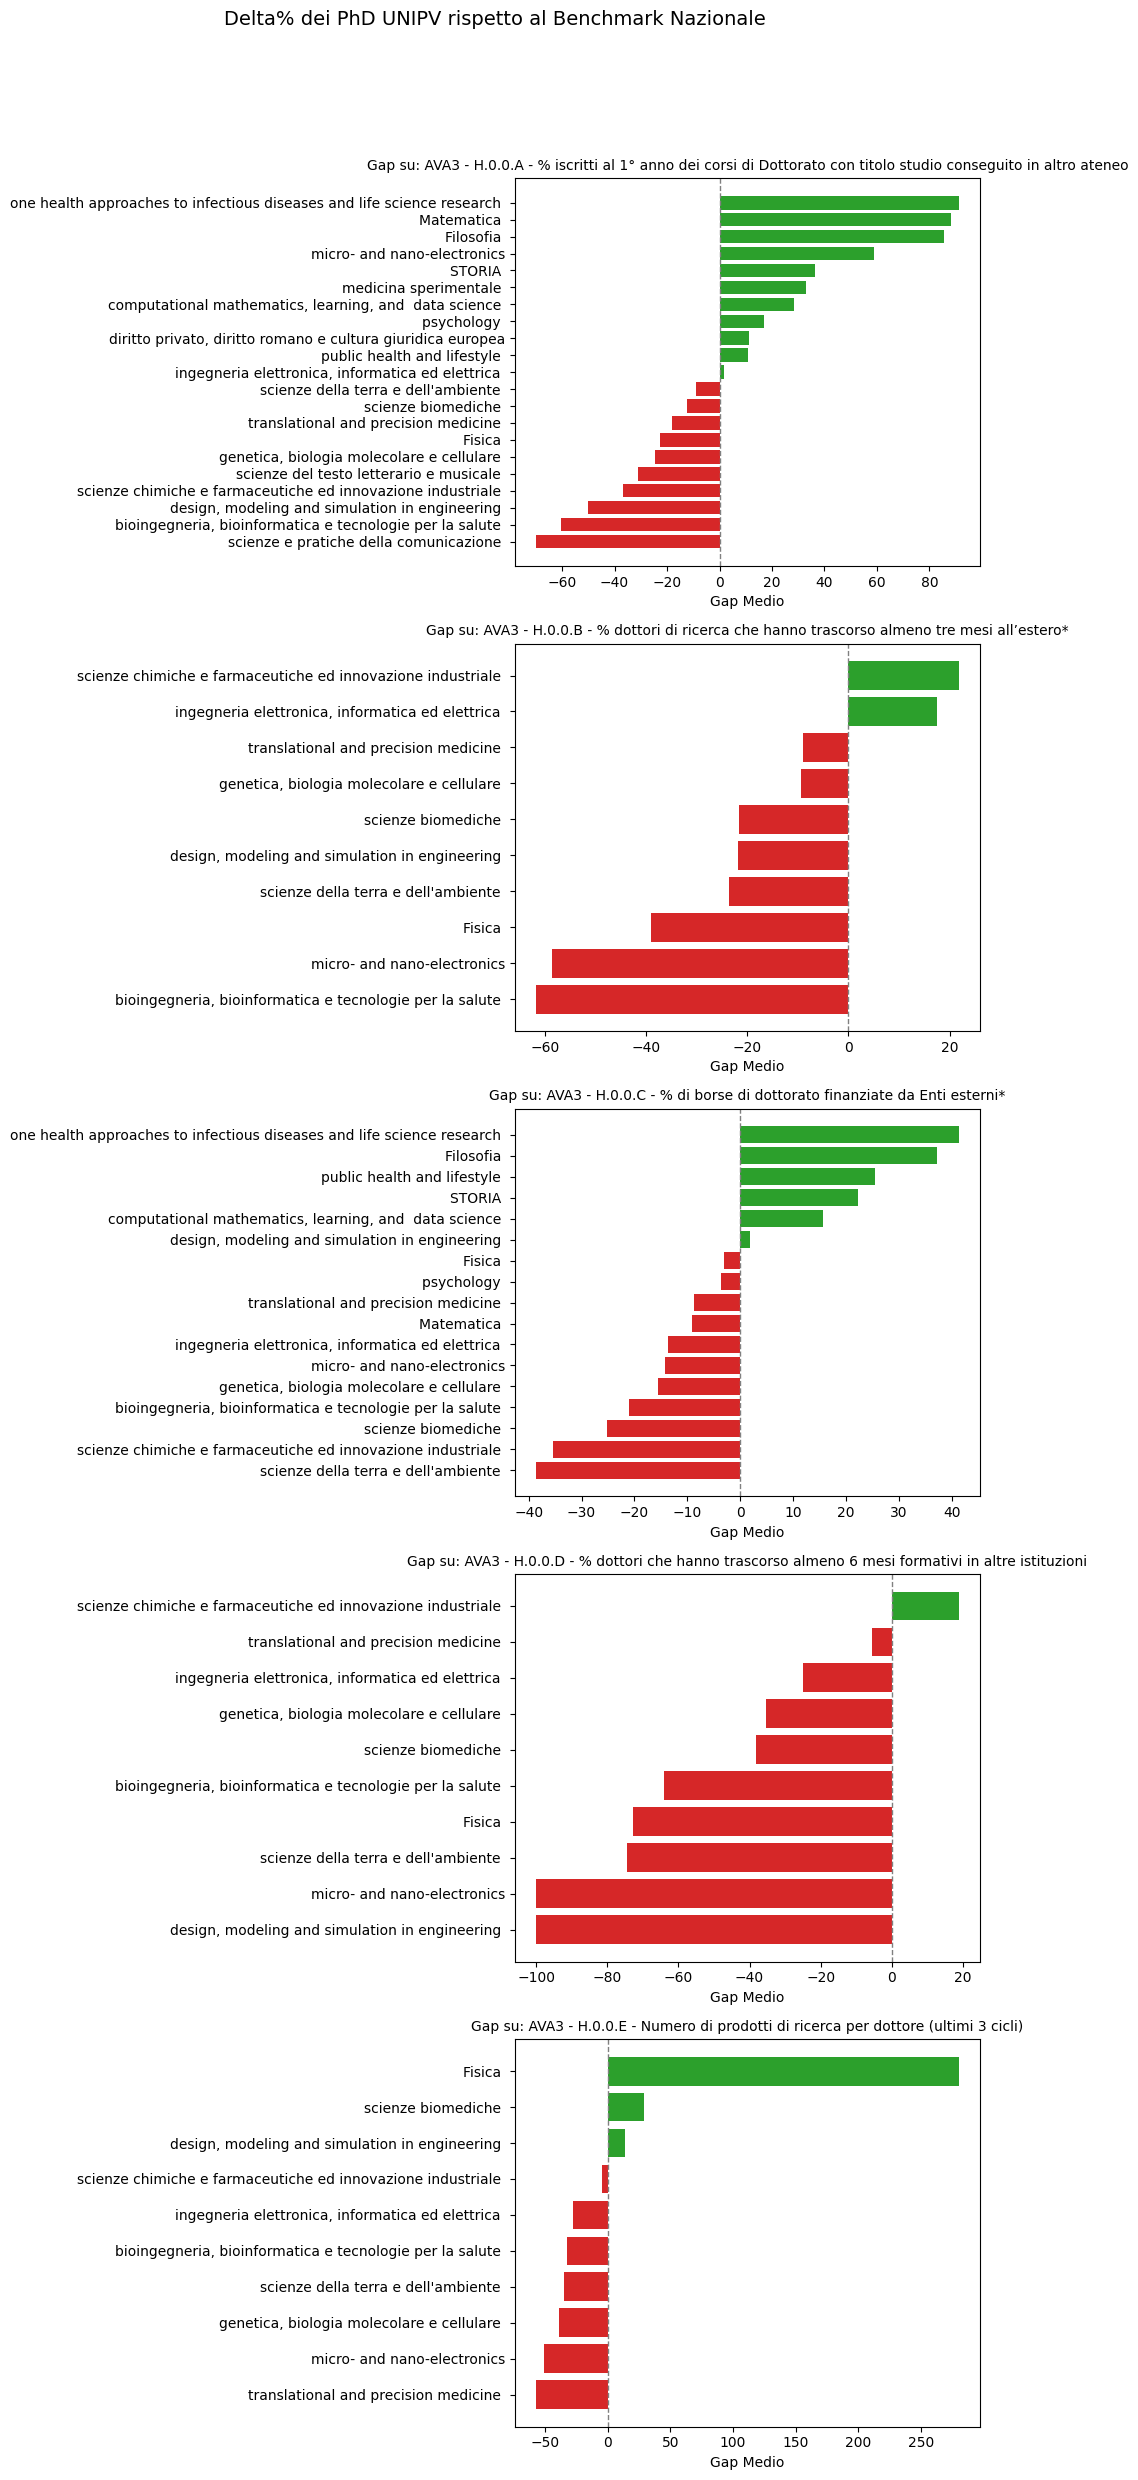

In [ ]:
# creazione df con gap vs ita
dfb2 = dfb.groupby(['Indicatore', 'Corso'])['Delta_vs_ITA'].mean().reset_index()
dfb2.rename(columns={'Delta_vs_ITA': 'Gap_medio_vs_ITA'}, inplace=True)
display(dfb2.head())
nan_counts = dfb2.isna().sum()
print(nan_counts)

# creazione griglia di grafici: un grafico per indicatore con i gap di ogni phd dal benchmark nazionale

# Get the unique indicators
indicatori = dfb2['Indicatore'].unique()
num_indicators = len(indicatori)

# Calculate the number of rows and columns needed for the grid
ncols = 1  # You can adjust the number of columns as needed
nrows = (num_indicators + ncols - 1) // ncols  # Ceiling division to ensure enough rows

# Create the figure and grid of axes (subplots)
# figsize adapts to the number of rows to avoid squashed plots
fig, axes = plt.subplots(nrows, ncols, figsize=(10, 5 * nrows), squeeze=False)

# Flatten the array of axes to easily iterate with a single index
axes = axes.flatten()

# 3. Iterate over each indicator to create its respective plot
for i, indicatore in enumerate(indicatori):
    ax = axes[i] # Select the correct axis for the current plot

    # Filter the DataFrame for the current indicator
    plot_dfb = dfb2[dfb2['Indicatore'] == indicatore].copy()

    # If there is no data for this indicator, skip to the next one
    if plot_dfb.empty:
        continue

    plot_dfb = plot_dfb.sort_values('Gap_medio_vs_ITA')

    # Values and colors (same logic as before, but on the filtered 'plot_df')
    vals = plot_dfb['Gap_medio_vs_ITA'].values
    labels = plot_dfb['Corso'].values
    colors = np.where(vals >= 0, 'tab:green', 'tab:red')

    # Draw the bars on the current axis 'ax' (instead of 'plt')
    ax.barh(labels, vals, color=colors)

    # Apply the formatting to the current axis 'ax'
    #ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
    ax.axvline(0, linestyle='--', linewidth=1, color='gray')

    # Set specific titles and labels for the subplot
    ax.set_title(f"Gap su: {indicatore}", fontsize=10) # Reduced fontsize for better fit
    ax.set_xlabel("Gap Medio")

# 4. Clean up unused axes
# If the number of indicators is odd (e.g., 3) and we have a 2x2 grid,
# the last axis would remain empty. This code hides it.
for j in range(num_indicators, len(axes)):
    axes[j].axis('off')

# Add a main title to the entire figure
fig.suptitle("Delta% dei PhD UNIPV rispetto al Benchmark Nazionale", fontsize=14, y=1.02)

# Optimize layout to prevent overlaps
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # rect to make space for suptitle

plt.show()

,Indicatore,Corso,Gap_medio_vs_REG
0,AVA3 - H.0.0.A - % iscritti al 1° anno dei cor...,Filosofia,74.807667
1,AVA3 - H.0.0.A - % iscritti al 1° anno dei cor...,Fisica,-20.940331
2,AVA3 - H.0.0.A - % iscritti al 1° anno dei cor...,Matematica,95.468231
3,AVA3 - H.0.0.A - % iscritti al 1° anno dei cor...,STORIA,23.842995
4,AVA3 - H.0.0.A - % iscritti al 1° anno dei cor...,"bioingegneria, bioinformatica e tecnologie per...",-59.724340


Indicatore          0
Corso               0
Gap_medio_vs_REG    0
dtype: int64


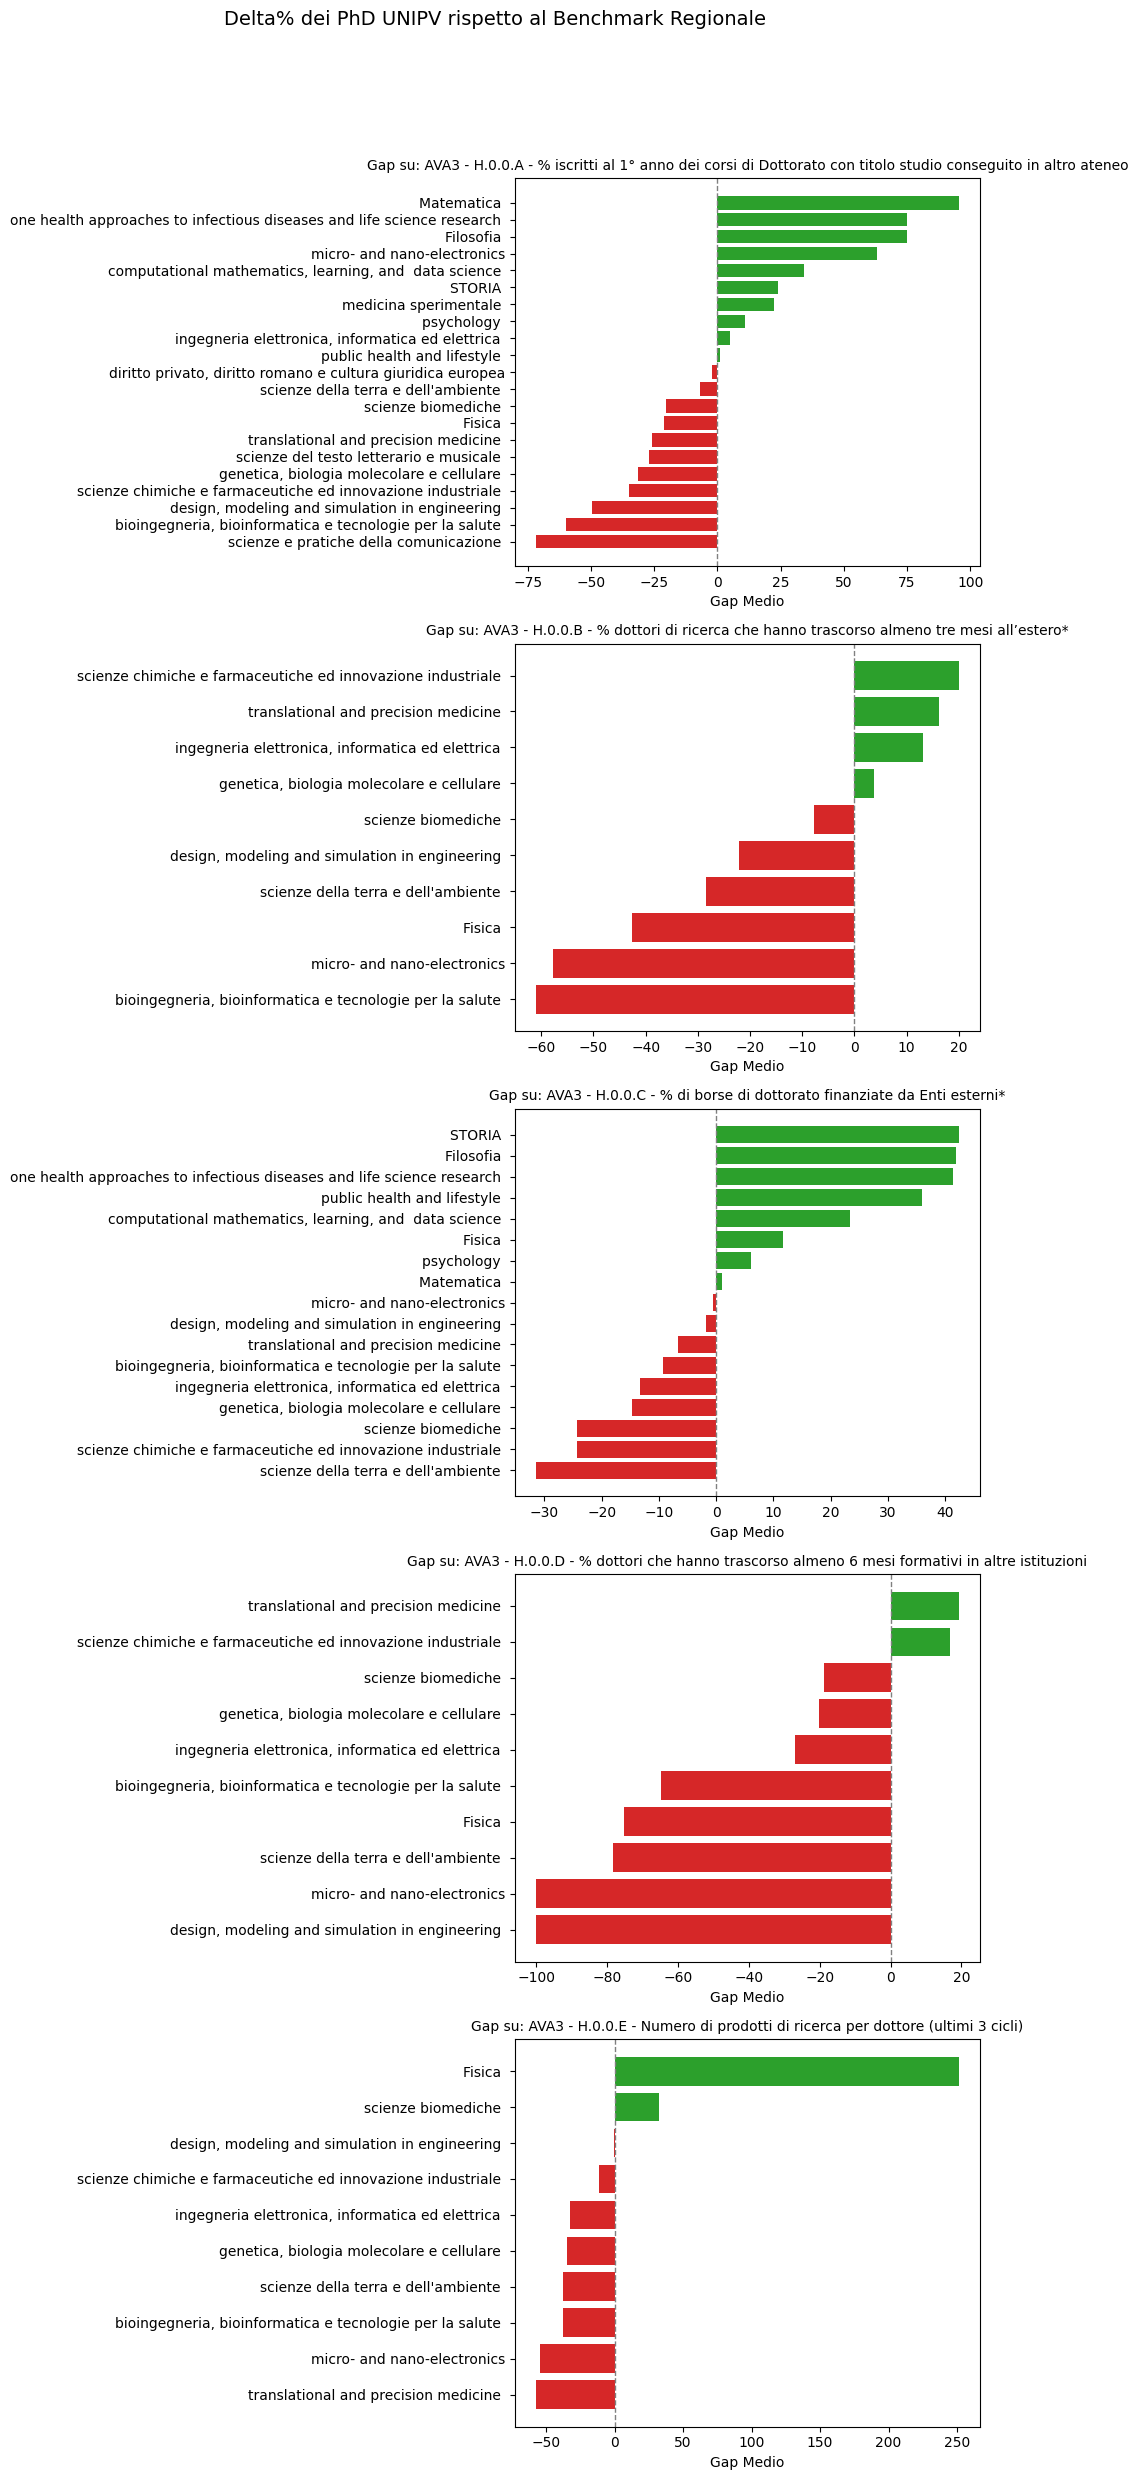

In [ ]:
# creazione df con gap vs regione
dfb3 = dfb.groupby(['Indicatore', 'Corso'])['Delta_vs_REG'].mean().reset_index()
dfb3.rename(columns={'Delta_vs_REG': 'Gap_medio_vs_REG'}, inplace=True)
display(dfb3.head())
nan_counts = dfb3.isna().sum()
print(nan_counts)

# creazione griglia di grafici: un grafico per indicatore con i gap di ogni phd dal benchmark regionale

# Get the unique indicators
indicatori = dfb3['Indicatore'].unique()
num_indicators = len(indicatori)

# Calculate the number of rows and columns needed for the grid
ncols = 1  # You can adjust the number of columns as needed
nrows = (num_indicators + ncols - 1) // ncols  # Ceiling division to ensure enough rows

# Create the figure and grid of axes (subplots)
# figsize adapts to the number of rows to avoid squashed plots
fig, axes = plt.subplots(nrows, ncols, figsize=(10, 5 * nrows), squeeze=False)

# Flatten the array of axes to easily iterate with a single index
axes = axes.flatten()

# 3. Iterate over each indicator to create its respective plot
for i, indicatore in enumerate(indicatori):
    ax = axes[i] # Select the correct axis for the current plot

    # Filter the DataFrame for the current indicator
    plot_dfb = dfb3[dfb3['Indicatore'] == indicatore].copy()

    # If there is no data for this indicator, skip to the next one
    if plot_dfb.empty:
        continue

    plot_dfb = plot_dfb.sort_values('Gap_medio_vs_REG')

    # Values and colors (same logic as before, but on the filtered 'plot_df')
    vals = plot_dfb['Gap_medio_vs_REG'].values
    labels = plot_dfb['Corso'].values
    colors = np.where(vals >= 0, 'tab:green', 'tab:red')

    # Draw the bars on the current axis 'ax' (instead of 'plt')
    ax.barh(labels, vals, color=colors)

    # Apply the formatting to the current axis 'ax'
    ax.axvline(0, linestyle='--', linewidth=1, color='gray')

    # Set specific titles and labels for the subplot
    ax.set_title(f"Gap su: {indicatore}", fontsize=10) # Reduced fontsize for better fit
    ax.set_xlabel("Gap Medio")

# 4. Clean up unused axes
# If the number of indicators is odd (e.g., 3) and we have a 2x2 grid,
# the last axis would remain empty. This code hides it.
for j in range(num_indicators, len(axes)):
    axes[j].axis('off')

# Add a main title to the entire figure
fig.suptitle("Delta% dei PhD UNIPV rispetto al Benchmark Regionale", fontsize=14, y=1.02)

# Optimize layout to prevent overlaps
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # rect to make space for suptitle

plt.show()

# 3 - Clustering

**Clustering senza intervallo di confidenza**

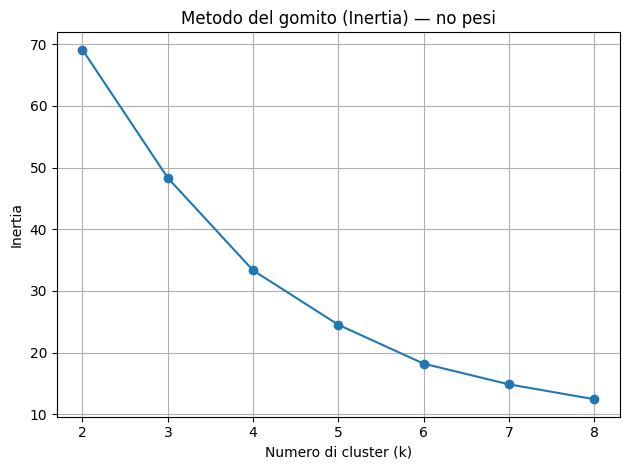

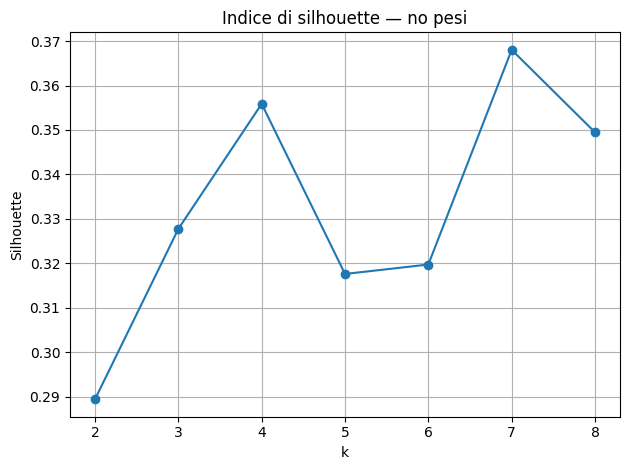

In [ ]:
# =======================
# CLUSTERING DOTTORATI — Den ≥ 10, NESSUN PESO
# =======================

import re
import numpy as np
import pandas as pd

# 0) PREPARAZIONE DATI (minima, no IC, solo verdi)
dfw = df.copy()
mask_semaforo = dfw['Robustezza'].isin(['Verde (robusto)'])
dfw = dfw[mask_semaforo].copy()

# Conversioni numeriche robuste (solo ciò che serve)
for col in ['Ind_PHD', 'Ind_ITA', 'Ind_REGIONE']:
    if col in dfw.columns:
        dfw[col] = (dfw[col].astype(str)
                              .str.replace(',', '.', regex=False)
                              .replace({'nan': np.nan, 'None': np.nan, '': np.nan}))
        dfw[col] = pd.to_numeric(dfw[col], errors='coerce')

for col in ['Num', 'Den', 'Anno']:
    if col in dfw.columns:
        dfw[col] = pd.to_numeric(dfw[col], errors='coerce')

# Estrai codice indicatore (H.0.0.A ... H.0.0.E) se not present
if 'Codice_ind' not in dfw.columns:
    def estrai_codice_indicatore(txt):
        if pd.isna(txt): return np.nan
        m = re.search(r'H\.0\.0\.[A-E]', str(txt))
        return m.group(0) if m else np.nan
    dfw['Codice_ind'] = dfw['Indicatore'].apply(estrai_codice_indicatore)

# =======================
# 1) MATRICE CORSO × INDICATORE — media SEMPLICE 2020–2024 (nessun peso)
# =======================
agg = (
    dfw.groupby(['Corso','Codice_ind'], as_index=False)
       .agg(Ind_media=('Ind_PHD', 'mean'))
)
df_cluster = agg.pivot(index='Corso', columns='Codice_ind', values='Ind_media')

# =======================
# 2) IMPUTAZIONE (KNN) + 3) STANDARDIZZAZIONE
# =======================
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

X = df_cluster.values
if np.isnan(X).any():
    imputer = KNNImputer(n_neighbors=3)
    X_imputed = imputer.fit_transform(X)
else:
    X_imputed = X.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# =======================
# 4) SCELTA K: GOMITO + SILHOUETTE (NO pesi)
# =======================
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

K_range = range(2, 9)
inertia = []
silhouette = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_scaled)   # <-- NESSUN sample_weight
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels_k))

# Grafico gomito
plt.figure()
plt.plot(list(K_range), inertia, marker='o')
plt.title("Metodo del gomito (Inertia) — no pesi")
plt.xlabel("Numero di cluster (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.tight_layout()
plt.show()

# Grafico silhouette
plt.figure()
plt.plot(list(K_range), silhouette, marker='o')
plt.title("Indice di silhouette — no pesi")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.grid(True)
plt.tight_layout()
plt.show()

,Cluster
Corso,
Filosofia,1
Fisica,2
Matematica,1
STORIA,1
"bioingegneria, bioinformatica e tecnologie per la salute",0


,H.0.0.A,H.0.0.B,H.0.0.C,H.0.0.D,H.0.0.E
Cluster,,,,,
0,0.306,0.224,0.545,0.081,8.500
1,0.665,0.222,0.823,0.081,13.645
2,0.279,0.220,0.684,0.056,42.184
3,0.299,0.417,0.457,0.193,9.016


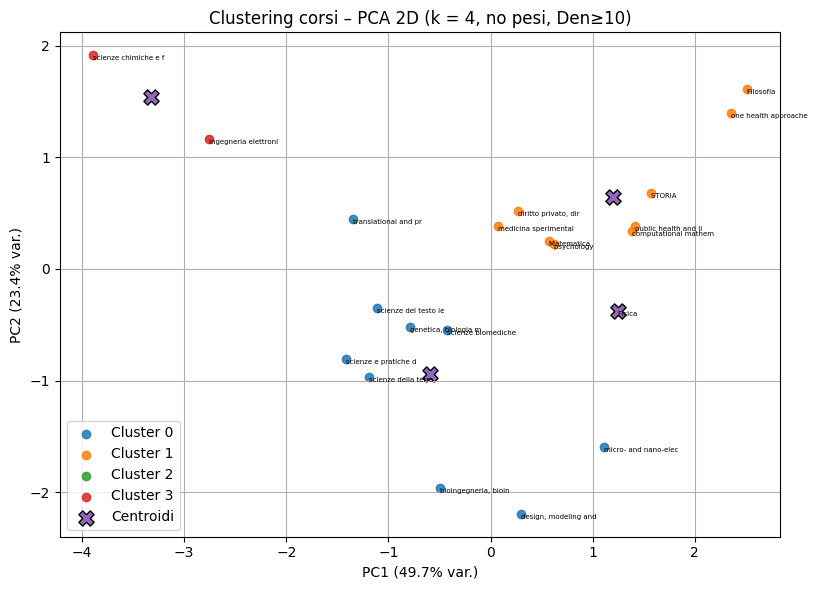

In [ ]:
# =======================
# 5) FIT DEFINITIVO
# =======================
k = 4  # <-- k scelto
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

# Assegna cluster ai corsi
df_clusters = pd.DataFrame({
    'Corso': df_cluster.index,
    'Cluster': labels
}).set_index('Corso')

# Profili medi dei cluster sui valori ORIGINALI (non standardizzati)
cluster_profile = (
    pd.DataFrame(X_imputed, index=df_cluster.index, columns=df_cluster.columns)
      .join(df_clusters)
      .groupby('Cluster')
      .mean(numeric_only=True)
)

display(df_clusters.head())
display(cluster_profile.round(3))

# =======================
# 6) PCA 2D + scatter dei corsi per cluster
# =======================
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

plot_df = pd.DataFrame(coords, index=df_cluster.index, columns=['PC1','PC2']).join(df_clusters)

plt.figure(figsize=(8, 6))
for cl in sorted(plot_df['Cluster'].unique()):
    sub = plot_df[plot_df['Cluster'] == cl]
    plt.scatter(sub['PC1'], sub['PC2'], label=f"Cluster {cl}", alpha=0.85)

centroids = plot_df.groupby('Cluster')[['PC1','PC2']].mean().reset_index()
plt.scatter(centroids['PC1'], centroids['PC2'], marker='X', s=120, edgecolor='k', linewidths=1.0, label='Centroidi')

var_exp = pca.explained_variance_ratio_ * 100
plt.xlabel(f"PC1 ({var_exp[0]:.1f}% var.)")
plt.ylabel(f"PC2 ({var_exp[1]:.1f}% var.)")
plt.title(f"Clustering corsi – PCA 2D (k = {k}, no pesi, Den≥10)")
plt.grid(True); plt.legend(loc='best'); plt.tight_layout()

# Etichette corte dei corsi
for i, corso in enumerate(plot_df.index):
    x, y = plot_df.iloc[i][["PC1", "PC2"]]
    plt.text(x, y, str(corso)[:20], fontsize=5, ha='left', va='top')

plt.show()

Interpretazione cluster

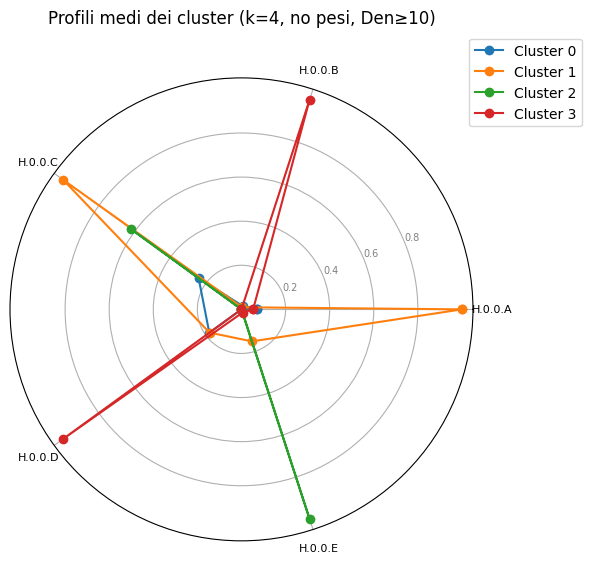

In [ ]:
# =======================
# 7) Radar chart: profili medi normalizzati (MinMax per colonna)
# =======================
import numpy as np
import matplotlib.pyplot as plt

def plot_radar_profiles(cluster_profile, title="Profili medi dei cluster (radar)"):
    indicators = cluster_profile.columns.tolist()
    n_vars = len(indicators)
    prof_norm = (cluster_profile - cluster_profile.min()) / (cluster_profile.max() - cluster_profile.min())
    prof_norm = prof_norm.fillna(0.0)

    angles = np.linspace(0, 2*np.pi, n_vars, endpoint=False).tolist()
    angles += angles[:1]

    plt.figure(figsize=(6,6))
    for cl_id, row in prof_norm.iterrows():
        vals = row.tolist(); vals += vals[:1]
        plt.polar(angles, vals, marker='o', label=f"Cluster {cl_id}")

    plt.xticks(angles[:-1], indicators, fontsize=8)
    plt.yticks([0.2,0.4,0.6,0.8], ["0.2","0.4","0.6","0.8"], color="grey", size=7)
    plt.title(title, fontsize=12, y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1.10))
    plt.tight_layout(); plt.show()

plot_radar_profiles(cluster_profile, title=f"Profili medi dei cluster (k={k}, no pesi, Den≥10)")

In [ ]:
# =======================
# 8) Output utili
# =======================
from pathlib import Path

def elenco_corsi_per_cluster(df_clusters, sort=True):
    out = {}
    for cl in sorted(df_clusters['Cluster'].unique()):
        corsi = df_clusters.index[df_clusters['Cluster'] == cl].tolist()
        out[cl] = sorted(corsi) if sort else corsi
    return out

elenco = elenco_corsi_per_cluster(df_clusters)
for cl, corsi in elenco.items():
    print(f"\nCluster {cl} (n={len(corsi)}):")
    for c in corsi:
        print(f"  - {c}")

# Tabella riassuntiva: profili medi + numerosità
n_per_cluster = df_clusters['Cluster'].value_counts().sort_index()
cluster_profile_with_n = cluster_profile.copy()
cluster_profile_with_n.insert(0, 'n_corsi', n_per_cluster.values)

print("\n== Profili medi dei cluster (con n_corsi) ==")
display(cluster_profile_with_n.round(3))


Cluster 0 (n=9):
  - bioingegneria, bioinformatica e tecnologie per la salute 
  - design, modeling and simulation in engineering 
  - genetica, biologia molecolare e cellulare 
  - micro- and nano-electronics
  - scienze biomediche 
  - scienze del testo letterario e musicale 
  - scienze della terra e dell'ambiente 
  - scienze e pratiche della comunicazione 
  - translational and precision medicine 

Cluster 1 (n=9):
  - Filosofia 
  - Matematica 
  - STORIA 
  - computational mathematics, learning, and  data science 
  - diritto privato, diritto romano e cultura giuridica europea
  - medicina sperimentale 
  - one health approaches to infectious diseases and life science research 
  - psychology 
  - public health and lifestyle 

Cluster 2 (n=1):
  - Fisica 

Cluster 3 (n=2):
  - ingegneria elettronica, informatica ed elettrica 
  - scienze chimiche e farmaceutiche ed innovazione industriale 

== Profili medi dei cluster (con n_corsi) ==


,n_corsi,H.0.0.A,H.0.0.B,H.0.0.C,H.0.0.D,H.0.0.E
Cluster,,,,,,
0,9,0.306,0.224,0.545,0.081,8.500
1,9,0.665,0.222,0.823,0.081,13.645
2,1,0.279,0.220,0.684,0.056,42.184
3,2,0.299,0.417,0.457,0.193,9.016


In [ ]:
# Salvataggi Excel
out_dir = Path("clustering_output_no_pesi")
out_dir.mkdir(parents=True, exist_ok=True)

(df_clusters.reset_index()
           .rename(columns={'index':'Corso'})
           .to_excel(out_dir / f"assegnazioni_k{k}.xlsx", index=False))

cluster_profile_with_n.to_excel(out_dir / f"profili_medi_k{k}.xlsx")

df_matrix_with_cluster = df_cluster.join(df_clusters, how='left')
df_matrix_with_cluster.to_excel(out_dir / f"matrice_corso_indicatore_k{k}.xlsx")

print(f"\nExcel salvati in: {out_dir.resolve()}")


Excel salvati in: /content/clustering_output_no_pesi
